# Demonstration Notebook
*Analyzing the National Tunnel Inventory with Marimo notebooks and altair for deploying a reactive analysis app.*
***

In [ ]:
import marimo as mo
import pandas as pd
import altair as alt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## Fetch NTI Dataset

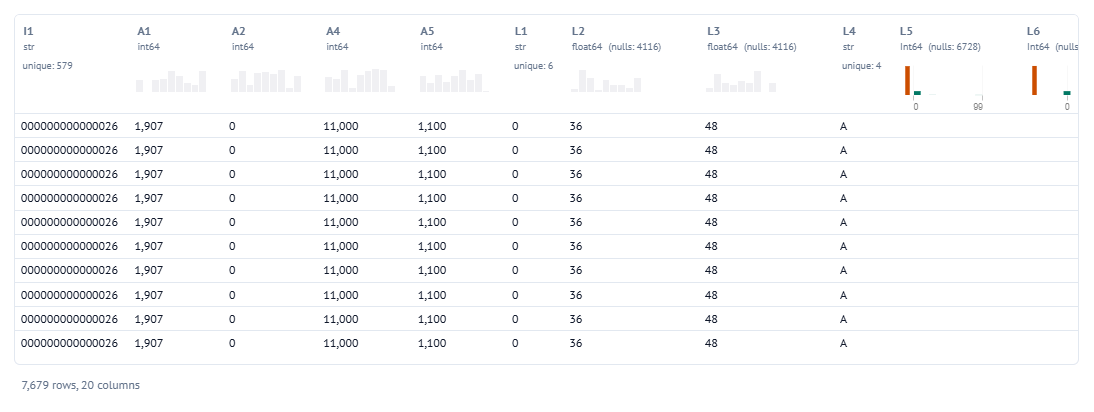

In [ ]:
import duckdb as ddb

df = ddb.sql(f"""
    SELECT 
        tunnels.I1,
        A1,
        A2,
        A4,
        A5,
        L1,
        L2,
        L3,
        L4,
        L5,
        L6,
        L7,
        L8,
        L9,
        EN::VARCHAR AS EN,
        CS1::INTEGER AS CS1,
        CS2::INTEGER AS CS2,
        CS3::INTEGER AS CS3,
        CS4::INTEGER AS CS4,
        TOTALQTY::INTEGER AS TOTALQTY

    FROM 'tunnels.csv'
        INNER JOIN 'elements.csv'
        ON tunnels.I1 = elements.I1;
    """).df()

df

## Interactive Tool

In [ ]:
# Calculate element condition percentages
df['PCT_CS1'] = df.CS1 / df.TOTALQTY
df['PCT_CS2'] = df.CS2 / df.TOTALQTY
df['PCT_CS3'] = df.CS3 / df.TOTALQTY
df['PCT_CS4'] = df.CS4 / df.TOTALQTY

EN_options = df.EN.unique()

# Create a form with multiple elements.
# User must submit the form for a plot to be generated.


elems=mo.ui.multiselect(options=EN_options, label="Elements")
conds=mo.ui.range_slider(start=1, stop=4, step=1, label="Condition States")
mo.md(f'''
    **Select a combination of tunnel elements and condition states**

    {elems}

    {conds}
''')



# form = (
#     mo.md('''
#     **Select a combination of tunnel elements and condition states**

#     {elems}

#     {conds}
# ''')
#     .batch(
#         elems=mo.ui.multiselect(options=EN_options, label="Elements"),
#         conds=mo.ui.range_slider(start=1, stop=4, step=1, label="Condition States"),
#     )
#     .form(show_clear_button=True, bordered=True)
# )

# form

<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>Select a combination of tunnel elements and condition states</strong></span>
<span class="paragraph"><marimo-ui-element object-id='Xref-0' random-id='5ac82f26-92a0-5184-1b38-012c70c3247c'><marimo-multiselect data-initial-value='[]' data-label='&quot;&lt;span class=&#92;&quot;markdown prose dark:prose-invert contents&#92;&quot;&gt;&lt;span class=&#92;&quot;paragraph&#92;&quot;&gt;Elements&lt;/span&gt;&lt;/span&gt;&quot;' data-options='[&quot;10001&quot;,&quot;10005&quot;,&quot;10011&quot;,&quot;10021&quot;,&quot;10041&quot;,&quot;10049&quot;,&quot;10051&quot;,&quot;10111&quot;,&quot;10158&quot;,&quot;10300&quot;,&quot;10500&quot;,&quot;10600&quot;,&quot;10601&quot;,&quot;10000&quot;,&quot;10101&quot;,&quot;10159&quot;,&quot;10161&quot;,&quot;10170&quot;,&quot;10200&quot;,&quot;10201&quot;,&quot;10301&quot;,&quot;10400&quot;,&quot;10475&quot;,&quot;10550&quot;,&quot;10620&quot;,&quot;10650&quot;,&quot;10700&quot;,&quot;10750&quot;,&quot;10800&quot;,&quot;10850&quot;,&quot;10890&quot;,&quot;10910&quot;,&quot;10911&quot;,&quot;10031&quot;,&quot;10055&quot;,&quot;10132&quot;,&quot;10179&quot;,&quot;10950&quot;,&quot;10003&quot;,&quot;10006&quot;,&quot;10007&quot;,&quot;10030&quot;,&quot;10080&quot;,&quot;10090&quot;,&quot;10131&quot;,&quot;10621&quot;,&quot;10870&quot;,&quot;10952&quot;,&quot;10059&quot;,&quot;10002&quot;,&quot;10019&quot;,&quot;10140&quot;,&quot;10061&quot;,&quot;10119&quot;,&quot;10139&quot;,&quot;10951&quot;,&quot;10010&quot;,&quot;10012&quot;,&quot;10120&quot;,&quot;10151&quot;,&quot;10122&quot;,&quot;10160&quot;,&quot;10009&quot;,&quot;10033&quot;,&quot;10070&quot;,&quot;10091&quot;,&quot;10099&quot;,&quot;10069&quot;,&quot;10130&quot;,&quot;10135&quot;,&quot;10169&quot;,&quot;10109&quot;,&quot;10020&quot;,&quot;10072&quot;,&quot;10133&quot;,&quot;10071&quot;,&quot;10171&quot;,&quot;10029&quot;,&quot;10134&quot;,&quot;10039&quot;,&quot;10089&quot;,&quot;10004&quot;,&quot;10121&quot;,&quot;10036&quot;]' data-full-width='false'></marimo-multiselect></marimo-ui-element></span>
<span class="paragraph"><marimo-ui-element object-id='Xref-1' random-id='37210d4b-c370-3e9c-31d0-8576a459c6f3'><marimo-range-slider data-initial-value='[1,4]' data-label='&quot;&lt;span class=&#92;&quot;markdown prose dark:prose-invert contents&#92;&quot;&gt;&lt;span class=&#92;&quot;paragraph&#92;&quot;&gt;Condition States&lt;/span&gt;&lt;/span&gt;&quot;' data-start='1' data-stop='4' data-step='1' data-steps='[]' data-debounce='false' data-orientation='&quot;horizontal&quot;' data-show-value='false' data-full-width='false' data-disabled='false'></marimo-range-slider></marimo-ui-element></span></span>

In [ ]:
# mo.stop(form.value is None, mo.md("Submit the form to continue"))

_df = df

# if (form.value != None):
_df = _df[_df.EN.isin(elems.value)].copy()
fetched_ids = _df.I1

# Calculate the number of truck cycles experienced
_df['RECENT_WORK'] = _df[['A1','A2']].max(axis=1).astype(int)
_df['AGE']  = 2026 - _df.RECENT_WORK.astype(int)
_df['ADTT'] = _df.A5.astype(int)
_df['TRUCK_CYCLES'] = _df.ADTT * _df.AGE

# Aggregate the condition states
_cols = []
_cond_range = range(conds.value[0], conds.value[1] + 1)
for _cond in (_cond_range):
    _cols.append(f"PCT_CS{_cond}")
    _colname = " + ".join(_cols)
    _df[_colname] = _df[_cols].sum(axis=1)

fig1 = mo.ui.altair_chart(alt.Chart(_df).mark_point().encode(
    x='TRUCK_CYCLES',
    y=_colname,
    color='EN'
))

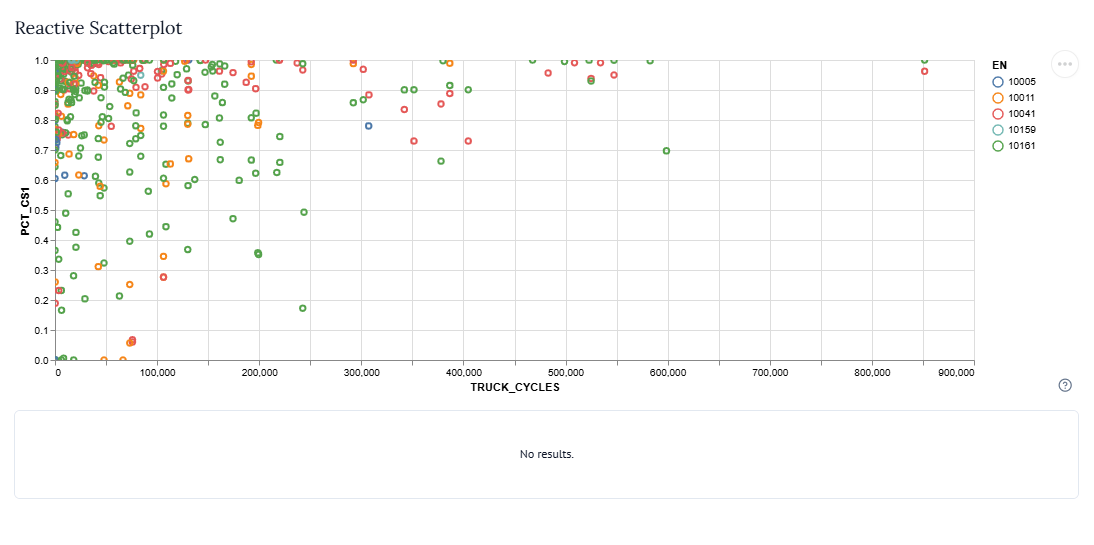

In [ ]:
# Display the plot
if (len(elems.value) > 0):
    _fig = fig1
    _tbl = mo.ui.table(_fig.value)
else:
    _fig = mo.md("Select one or more elements in the dropdown above to view this chart.")
    _tbl = mo.md("")

mo.vstack([
    mo.md("### Reactive Scatterplot"),
    _fig,
    _tbl
])